In [40]:
import numpy as np
import pandas as pd

In [41]:
np.random.seed(42)

In [42]:
normal_data=np.random.normal(loc=50,scale=5,size=300)

In [43]:
outliers=np.random.uniform(low=500,high=1000,size=5)

In [44]:
raw_data=np.concatenate([normal_data,outliers]).reshape(-1,1)

In [45]:
print(f'Lenght of data={len(raw_data)} | Mean={np.mean(raw_data)} | Median={np.median(raw_data)}')

Lenght of data=305 | Mean=62.27997224920672 | Median=50.337641023439616


In [46]:
import seaborn as sns

<Axes: ylabel='Count'>

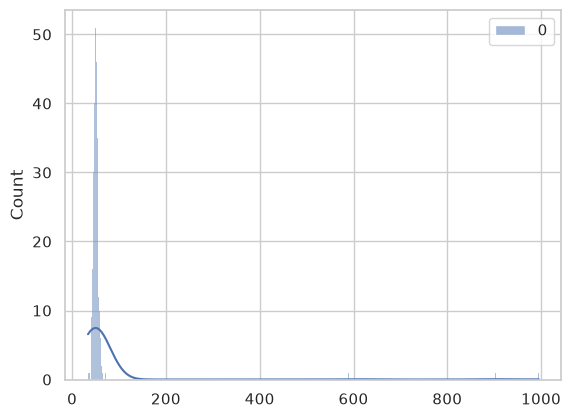

In [47]:
sns.histplot(raw_data,kde=True,bins='fd')

<Axes: >

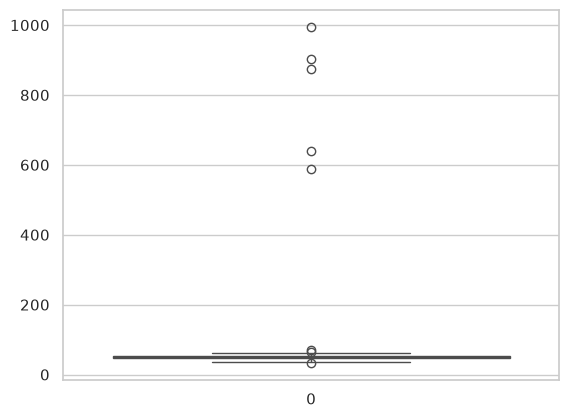

In [48]:
sns.boxplot(raw_data)

In [49]:
print('Using Standard Scaler:Z-score')

Using Standard Scaler:Z-score


In [50]:
from sklearn.preprocessing import StandardScaler as SS

In [51]:
SS_data=SS().fit_transform(raw_data)

<Axes: ylabel='Count'>

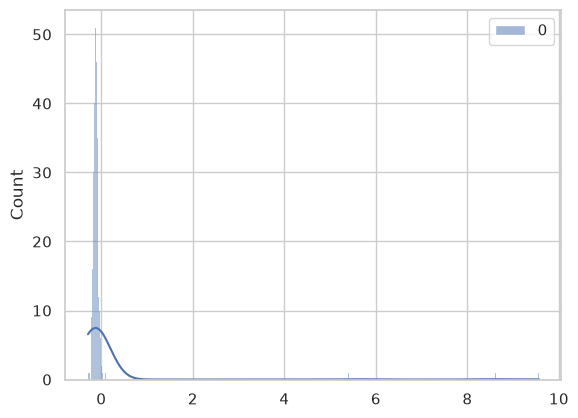

In [52]:
sns.histplot(SS_data,kde=True,bins='fd')

<Axes: >

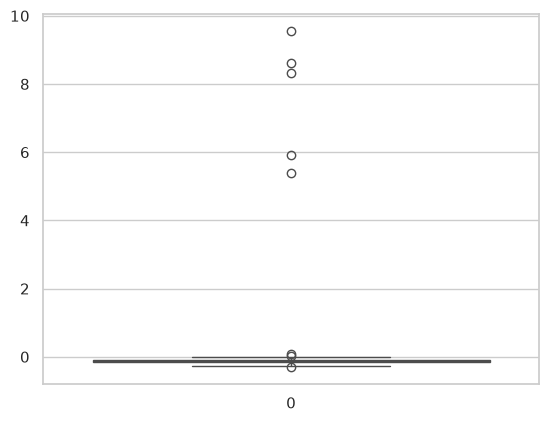

In [53]:
sns.boxplot(SS_data)

In [54]:
#NO change as larger values manipulated mean and standard deviation and also the standard deviation is inflated. 

In [55]:
print('Using Robust Scaler:IQR')

Using Robust Scaler:IQR


In [56]:
from sklearn.preprocessing import RobustScaler as RS

In [57]:
RS_data=RS().fit_transform(raw_data)

<Axes: ylabel='Count'>

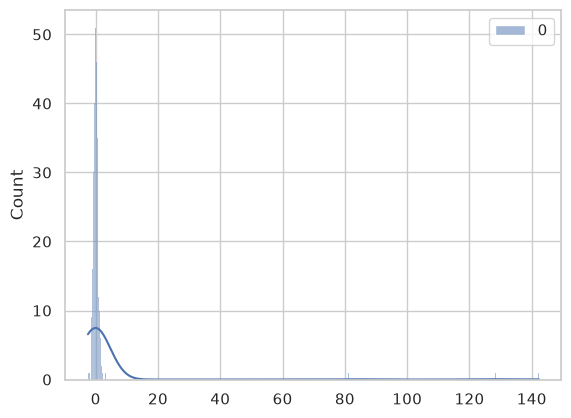

In [58]:
sns.histplot(RS_data,kde=True,bins='fd')

<Axes: >

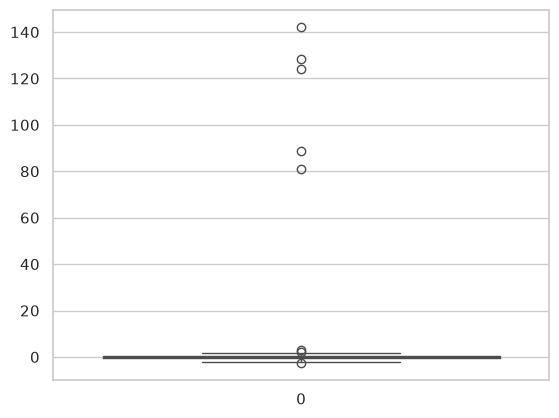

In [59]:
sns.boxplot(RS_data)

In [60]:
#Here as you can see the scale is much larger. The biggest outlier is 140, whereas earlier it was 10, so the distance between the normal data points and anomalies is quite large. 

In [61]:
print('Using isolation forest for detecting anomalies')

Using isolation forest for detecting anomalies


In [62]:
from sklearn.ensemble import IsolationForest as IF

In [63]:
IF_label=IF(contamination='auto',random_state=42).fit_predict(raw_data)

In [64]:
print(f'Anomalies detected={np.sum(IF_label==-1)}')

Anomalies detected=30


In [65]:
sns.set_theme(style='whitegrid')

In [66]:
y_dummy=np.zeros_like(raw_data)

In [67]:
import matplotlib.pyplot as plt

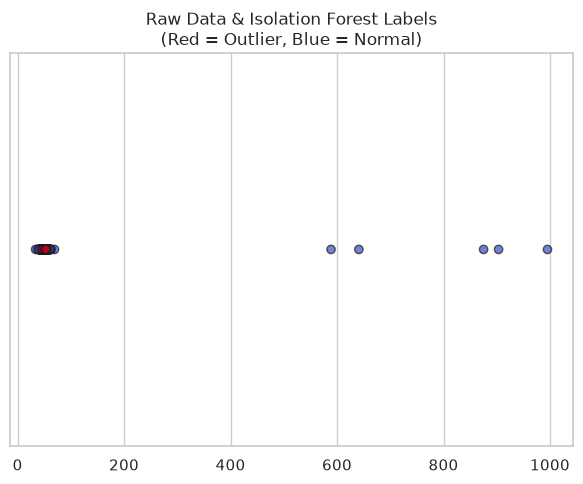

In [68]:
plt.figure(figsize=(6,5))
plt.scatter(x=raw_data,y=y_dummy,c=IF_label,alpha=0.7,cmap='coolwarm',edgecolor='k')
plt.title("Raw Data & Isolation Forest Labels\n(Red = Outlier, Blue = Normal)")
plt.yticks([])
plt.tight_layout()
plt.show()

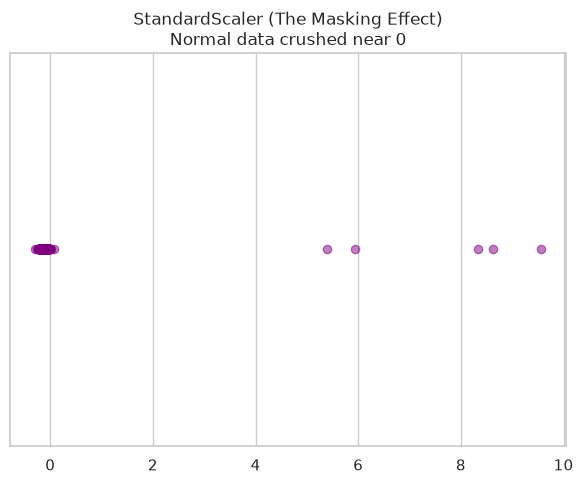

In [69]:
plt.figure(figsize=(6, 5))
plt.scatter(SS_data, y_dummy, color='purple', alpha=0.5)
plt.title("StandardScaler (The Masking Effect)\nNormal data crushed near 0")
plt.yticks([])
plt.tight_layout()
plt.show()

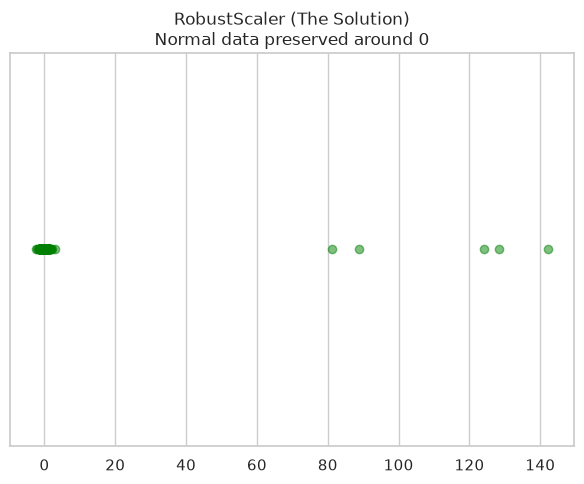

In [70]:
plt.figure(figsize=(6, 5))
plt.scatter(RS_data, y_dummy, color='green', alpha=0.5)
plt.title("RobustScaler (The Solution)\nNormal data preserved around 0")
plt.yticks([])
plt.tight_layout()
plt.show()

In [71]:
#33Summary:
##PICTURE!
#By comparing all these three graphs we analyze that for graph 1, when we are comparing with raw data, our outlier sits at a far value. That creates a huge gap between our original cluster data and the outliers, giving them an edge over algorithms like SVM and K&N. 

##PICTURE2
#In picture 2 you can see that the large values of 1000 are magnified to a small value 10, which creates a very small gap between our original cluster data and 10. The gap between the original cluster data is also diminished and so small that it cannot be used as they all are looking identical. That's why model 2 also fails. 

##PICTURE3
#In picture three we can see that now our outlier is at somewhat 140 and the data is clustered around 1. Also in the previous picture, picture 2, the data is heavily compressed and shifted towards the negative side that is below zero. As you can clearly see, the line in picture 2 is more on the negative side but in picture the data is properly clustered around zero. The outliers are also at the far value but not that far; the mean is not specifically highly edged towards them and they are in the safe space. 